<a href="https://colab.research.google.com/github/scalabrinig/cdProjetoAplicadoIV/blob/master/projeto/cd_projeto_aplicado_IV_doc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  <img src="https://raw.githubusercontent.com/scalabrinig/cdProjetoAplicadoIV/d093146488f56dfcf0ef286bcee8efe0e71b9c76/figuras/mackenzie_logo.jpg" width="25%" align="right"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2026/02**


# **Documentação do Projeto**

---

# **Título do Projeto**
---

## *Do Reservatório à Conta de Luz: Previsão de Risco Energético-Hídrico e Bandeiras Tarifárias no Brasil*

## Integrantes do Grupo

| Nome completo | Matrícula |
|---|---|
| Bruna Mendes Rocha | `10441296` |
| Cristiano Prado do Carmo | `10720249` |

# **Resumo**

O Brasil possui uma matriz elétrica predominantemente hidrelétrica, na qual os reservatórios das usinas funcionam como uma forma natural de armazenamento de energia. Nos últimos anos, o crescimento acelerado da geração solar e eólica tem introduzido uma nova dinâmica ao sistema: o excedente de geração renovável intermitente pode ser utilizado para reduzir o turbinamento das hidrelétricas, preservando os níveis de água armazenada. Este fenômeno é conhecido como complementaridade hidro-solar. Ao mesmo tempo, quando essa relação não é bem administrada, o sistema pode enfrentar tanto o descarte de energia renovável, conhecido como curtailment, quanto o risco de esgotamento dos reservatórios, com impacto direto na segurança do fornecimento e no valor da tarifa de energia paga pela população. 

Este projeto propõe um modelo de previsão de séries temporais para estimar o nível futuro de Energia Armazenada (EAR) nos reservatórios do Sistema Interligado Nacional (SIN), utilizando como variáveis explicativas a Energia Natural Afluente (ENA) e a geração solar/eólica, que são dados públicos disponibilizados pelo Operador Nacional do Sistema Elétrico (ONS). A partir dessa previsão, são derivados indicadores de risco energético-hídrico e uma estimativa de bandeira tarifária, com base no histórico de acionamento publicado pela ANEEL. A abordagem metodológica prevê o uso de modelos estatísticos de séries temporais (como SARIMAX), complementados por técnicas de aprendizado de máquina, gerando como produto final um painel com duas camadas de informação: uma técnica, voltada à operação do sistema, e outra pública, voltada à comunicação acessível do risco à população.

# **Introdução**

## Contexto

O Brasil possui uma matriz elétrica predominantemente hidrelétrica, na qual os reservatórios das usinas funcionam como uma forma natural de armazenamento de energia: a água represada equivale, em termos energéticos, a uma reserva que pode ser utilizada quando necessário. Nos últimos anos, esse sistema vem passando por uma transformação relevante, marcada pelo crescimento acelerado da geração solar e eólica na matriz nacional. Esse avanço, embora positivo do ponto de vista da diversificação e da sustentabilidade energética, tem introduzido um novo desafio operacional: em determinados momentos, a oferta de energia renovável intermitente supera a capacidade do sistema de absorvê-la integralmente, fenômeno conhecido como *curtailment* (corte de geração). Por outro lado, esse mesmo crescimento também viabiliza um efeito benéfico pouco explorado fora do meio técnico: a chamada complementaridade hidro-solar, em que o excedente de geração solar/eólica permite reduzir o turbinamento das hidrelétricas em determinados períodos, preservando os níveis de água armazenada nos reservatórios.

## Motivação

A relevância deste projeto se sustenta em dados recentes que evidenciam a intensidade e a atualidade do problema. Entre janeiro de 2025 e janeiro de 2026, a participação da energia solar na matriz elétrica brasileira saltou de 20,9% para 24,5%, consolidando-se como a segunda maior fonte do país, atrás apenas da geração hídrica, que no mesmo período recuou de 45,4% para 42,4% (ABSOLAR, 2026). Esse crescimento acelerado tem um custo operacional real: em 2025, o Brasil cortou aproximadamente 37 TWh de geração eólica e solar centralizada por meio do fenômeno de *curtailment*, volume três vezes maior que o registrado em 2024 e equivalente a quase toda a energia consumida em um ano por São Paulo, Guarulhos, Campinas e Santos juntas (CNN BRASIL, 2026). A evolução histórica reforça a tendência de agravamento: o curtailment médio era de apenas 0,1% em 2017, passou para 1,2% em 2021, 4,5% em 2023 e atingiu cerca de 20% em 2025, acompanhando o crescimento da geração distribuída no período (ENGIE, 2026). Os impactos não são apenas técnicos: um estudo da consultoria Volt Robotics estimou que o desperdício de energia renovável em 2025 gerou prejuízo de R$ 6,5 bilhões a 1.500 usinas renováveis centralizadas sob supervisão do ONS (CB INSIGHTS, 2026). Em resposta a esse cenário, o governo brasileiro introduziu em 2025 a Medida Provisória nº 1.304, criando um mecanismo de compensação para geração cortada e determinando ao ONS a implementação de protocolos mais claros de curtailment, evidenciando que o tema segue em pleno debate regulatório no país.

Episódios anteriores de crise já evidenciaram essa vulnerabilidade estrutural. Em 2001, quando cerca de 90% da energia elétrica brasileira tinha origem hídrica, o país enfrentou a chamada "Crise do Apagão", que resultou em um racionamento obrigatório de aproximadamente 20% no consumo de eletricidade em todo o território nacional, mantido por mais de nove meses. O evento expôs falhas de planejamento e a ausência de investimentos em geração e transmissão, evidenciando as fragilidades de um modelo fortemente dependente de uma única fonte de energia (SANTOS; NASCIMENTO, 2025). Duas décadas depois, em 31 de agosto de 2021, em meio à pior seca em 91 anos, a Câmara de Regras Excepcionais para Gestão Hidroenergética (CREG) determinou à ANEEL a criação da Bandeira Tarifária de Escassez Hídrica, no valor de R$ 142,00/MWh, patamar excepcional que vigorou até 15 de abril de 2022 (ANEEL; CREG, 2021). Na prática, essa bandeira representou um acréscimo de R$ 14,20 a cada 100 kWh consumidos, o maior já registrado na história do mecanismo de bandeiras tarifárias, criado pela ANEEL em 2015 (AGÊNCIA BRASIL, 2023). Esses episódios demonstram que a dependência excessiva de uma única fonte, sem mecanismos robustos de previsão e complementaridade, gera vulnerabilidade recorrente tanto para a operação do sistema elétrico quanto para o bolso da população brasileira.

## Objetivo geral

Desenvolver um modelo preditivo de séries temporais capaz de estimar o nível futuro de Energia Armazenada (EAR) nos reservatórios do Sistema Interligado Nacional (SIN), a partir de variáveis hidrológicas (Energia Natural Afluente — ENA) e de geração solar/eólica, gerando como produto derivado indicadores de risco energético-hídrico e uma estimativa de bandeira tarifária.

## Objetivos específicos

- Levantar e organizar dados históricos de EAR, ENA e geração por fonte, disponibilizados pelo Portal de Dados Abertos do ONS.
- Levantar o histórico de acionamento de bandeiras tarifárias, disponibilizado pelo Portal de Dados Abertos da ANEEL.
- Realizar análise exploratória e pré-processamento das séries temporais envolvidas.
- Desenvolver e validar um modelo estatístico/de aprendizado de máquina (ex.: SARIMAX) para previsão de EAR.
- Derivar, a partir da previsão de EAR, uma classificação de risco energético-hídrico e uma estimativa de bandeira tarifária.
- Apresentar os resultados por meio de um painel com duas camadas de informação: uma técnica (indicadores e previsões) e outra voltada à população (comunicação acessível do risco).

## Justificativa

Do ponto de vista científico, o projeto contribui ao explorar, de forma aplicada, a relação de complementaridade entre fontes renováveis intermitentes e a gestão de reservatórios hidrelétricos, tema já discutido na literatura acadêmica, como no estudo de Páez Mendieta e Hidalgo (2025), que demonstrou, para a bacia do Alto São Francisco, que a complementaridade hidro-solar permite aumentar o volume armazenado em reservatórios mesmo em cenários climáticos de redução de precipitação. Este projeto se diferencia ao aplicar essa mesma lógica de complementaridade em escala nacional (Sistema Interligado Nacional), com foco na previsão de série temporal e na tradução do resultado técnico em informação acessível à população, direção ainda pouco explorada na literatura consultada. Do ponto de vista social, o projeto se conecta ao **ODS 11 (Cidades e Comunidades Sustentáveis)**, na medida em que propõe uma ferramenta de apoio ao acesso seguro, previsível e planejável a um serviço essencial, a energia elétrica, para comunidades urbanas, tornando acessível à população uma informação hoje concentrada em relatórios técnicos especializados.

# **Descrição da base de dados**

Serão utilizadas duas fontes de dados públicas, oficiais e primárias, ambas disponibilizadas por órgãos do setor elétrico brasileiro:

**Portal de Dados Abertos do ONS (Operador Nacional do Sistema Elétrico)** — dados.ons.org.br

- **Energia Armazenada (EAR)**: nível de energia armazenada nos reservatórios das usinas hidrelétricas, por subsistema (Sudeste/Centro-Oeste, Sul, Nordeste, Norte), expressa em percentual da capacidade máxima de armazenamento. Série histórica disponível com granularidade diária.
- **Energia Natural Afluente (ENA)**: volume de água que aflui aos reservatórios, expressa em percentual da Média de Longo Termo (MLT) por subsistema. Série histórica disponível com granularidade diária.
- **Geração por Usina em Base Horária**: geração verificada por usina, incluindo fontes hidráulica, térmica, solar e eólica, com dados de 2000 até o presente. Os arquivos de 2000 a 2021 são organizados por ano; a partir de 2022, por mês.

**Portal de Dados Abertos da ANEEL (Agência Nacional de Energia Elétrica)**

- **Histórico de Acionamento de Bandeiras Tarifárias**: registro mensal da cor da bandeira tarifária vigente (verde, amarela, vermelha patamar 1, vermelha patamar 2, e a bandeira excepcional de escassez hídrica, criada em 2021), disponível desde 2015.

Ambas as fontes são de acesso público, gratuito, e fornecem dados estruturados em formato tabular (CSV), permitindo o processamento direto em ferramentas de análise de dados. O recorte temporal a ser utilizado no projeto, bem como o(s) subsistema(s) priorizado(s) para a modelagem, serão definidos durante a etapa de análise exploratória (Entrega 2/3), conforme a qualidade e completude dos dados verificadas na prática.

Cabe destacar que os dados de bandeira tarifária possuem granularidade mensal, enquanto os dados de EAR, ENA e geração possuem granularidade diária ou horária. Essa diferença de granularidade é tratada explicitamente na etapa de pré-processamento, quando as previsões diárias de EAR são agregadas à escala mensal necessária para a estimativa de bandeira tarifária, conforme detalhado na seção de EDA e Pré-processamento dos Dados.

# **Referencial Teórico**

A modelagem de séries temporais parte da identificação de suas componentes fundamentais: tendência (variação de longo prazo), sazonalidade (padrões que se repetem em intervalos regulares), ciclos (oscilações de duração variável, não fixa) e ruído (variação aleatória residual). A caracterização dessas componentes é feita por meio de análise gráfica, testes de estacionariedade (verificação de que média e variância se mantêm constantes ao longo do tempo) e das funções de Autocorrelação (ACF) e Autocorrelação Parcial (PACF), que indicam o grau de dependência entre observações passadas e futuras da série.

Entre as técnicas de modelagem, os modelos da família ARIMA (Autoregressive Integrated Moving Average) e sua extensão sazonal, o SARIMA, figuram entre as abordagens estatísticas mais consolidadas para previsão de séries temporais, sendo aplicáveis tanto a séries estacionárias quanto, após diferenciação, a séries não estacionárias com tendência e sazonalidade. Como alternativa ou complemento, técnicas de aprendizado de máquina, como Support Vector Machines (SVM) e redes neurais recorrentes, vêm sendo empregadas para capturar relações não lineares que os modelos estatísticos clássicos podem não representar adequadamente.

No contexto de reservatórios hidrelétricos, Mine e Tucci (2002) aplicaram um modelo ARIMA para prever a vazão afluente ao reservatório da Usina de Foz do Areia, no Rio Iguaçu, integrando a previsão à regra de operação da usina para conciliar geração de energia e controle de cheias. Os autores destacam como vantagem do ARIMA a simplicidade operacional, já que o modelo utiliza apenas o histórico da própria série local, mas apontam como limitação o atraso das previsões em relação ao comportamento real da série, atraso que se acentua quanto maior o horizonte de previsão, o que reforça a necessidade de avaliar cuidadosamente o alcance temporal desejado ao aplicar essa técnica ao presente projeto. É relevante notar que os autores já discutiam, à época, a complementaridade hídrica entre as regiões Sul e Sudeste do Brasil como tema de crescente interesse do setor elétrico, precedente direto da relação de complementaridade investigada neste trabalho.

Nunes, Veras e Silva (2023) compararam diretamente ARIMA e SVM na previsão de séries do sistema elétrico brasileiro (Preço de Liquidação das Diferenças e velocidade do vento), concluindo que a escolha entre as abordagens depende das características específicas de cada série, o que motiva, no presente projeto, considerar tanto o SARIMA quanto técnicas complementares de aprendizado de máquina, conforme já previsto nos objetivos específicos.

Por fim, Páez Mendieta e Hidalgo (2025), ao estudarem a complementaridade hidro-solar na bacia do Alto São Francisco, demonstraram, por meio de modelagem hidrológica e hidrelétrica, que a inserção de geração fotovoltaica projetada permite aumentar o volume armazenado em reservatórios mesmo em cenários climáticos de redução de precipitação. Esse resultado fundamenta, do ponto de vista físico, a hipótese central deste projeto, de que a geração solar e eólica pode ser utilizada como variável explicativa relevante na previsão da Energia Armazenada (EAR) dos reservatórios do Sistema Interligado Nacional.

Em conjunto, os trabalhos revisados indicam que modelos da família ARIMA/SARIMA constituem uma abordagem tecnicamente adequada e amplamente validada para a previsão de séries hidrológicas e energéticas no contexto brasileiro, ao mesmo tempo em que sinalizam a relevância de considerar suas limitações de horizonte de previsão e a possibilidade de complementação com técnicas de aprendizado de máquina, direções que serão exploradas nas próximas etapas deste projeto.


# **Diagrama de Solução**

A solução proposta é estruturada em um pipeline sequencial de seis etapas, ilustrado na Figura 1.

Na etapa de **coleta de dados**, séries históricas de Energia Armazenada (EAR) e Energia Natural Afluente (ENA), por subsistema, são obtidas diretamente do bucket público do ONS na AWS (`ons-aws-prod-opendata`), de forma automatizada e reprodutível, sem intervenção manual. O histórico de acionamento de bandeiras tarifárias é obtido do Portal de Dados Abertos da ANEEL.

Na etapa de **pré-processamento**, os dados são limpos e organizados, tratando eventuais valores faltantes e alinhando a diferença de granularidade entre as séries diárias (EAR, ENA) e a série mensal (bandeira tarifária).

A **análise exploratória** caracteriza as séries temporais quanto à estacionariedade, calcula as funções de Autocorrelação (ACF) e Autocorrelação Parcial (PACF), e aplica técnicas de decomposição para identificar as componentes de tendência, sazonalidade, ciclo e ruído, conforme detalhado na seção de EDA e Pré-processamento dos Dados.

Na etapa de **modelagem**, é ajustado um modelo SARIMAX para previsão da EAR, utilizando a ENA e a geração solar/eólica como variáveis exógenas, complementado por técnicas de aprendizado de máquina conforme necessário.

A **avaliação** do modelo é conduzida por meio de métricas de erro (RMSE, MAE), permitindo comparar diferentes configurações e validar a qualidade das previsões.

Por fim, a **camada de decisão** deriva, a partir da previsão de EAR, uma classificação de risco energético-hídrico e uma estimativa de bandeira tarifária, alimentando dois painéis de saída: um **painel técnico**, com os indicadores de EAR e o nível de risco, voltado à operação do sistema; e um **painel público**, com um semáforo de risco em linguagem acessível, voltado à comunicação com a população, em linha com o caráter extensionista do projeto e sua conexão com o ODS 11.

*Figura 1. Pipeline da solução proposta, do dado bruto à camada de comunicação.*

   <img src="../docs/img/pipeline_solucao_projeto.svg" alt="Pipeline da solução" width="800">


# **Cronograma**

| Período | Marco/Entrega oficial | Atividades planejadas |
|---|---|---|
| 29/09 – 05/10 | Checkpoint Etapa 3 (05/10) | Entrega da Etapa 2 (28/09). Início da Análise Exploratória real sobre os dados de EAR/ENA já coletados: verificação de estacionariedade, cálculo de ACF/PACF, decomposição em tendência, sazonalidade, ciclo e ruído. |
| 06/10 – 12/10 | — | Conclusão da EDA. Definição do(s) subsistema(s) e recorte temporal final para modelagem. Início do ajuste do modelo SARIMAX para previsão de EAR. |
| 13/10 – 19/10 | — | Refinamento do modelo, incorporando ENA e geração solar/eólica como variáveis exógenas. Cálculo das métricas de avaliação (RMSE, MAE). Testes preliminares de horizontes de previsão. |
| 20/10 – 26/10 | **Entrega Etapa 3 (26/10)** | Consolidação dos resultados do modelo base. Redação da seção de Resultados. Revisão geral e envio da Etapa 3. |
| 27/10 – 02/11 | Checkpoint Etapa 4 (02/11) | Buffer de revisão. Início da camada de decisão: regras de classificação de risco energético-hídrico e aproximação da previsão de bandeira tarifária a partir da EAR prevista. |
| 03/11 – 09/11 | — | Desenvolvimento do painel de apresentação dos resultados (camada técnica e camada pública), integrado ao notebook. |
| 10/11 – 16/11 | — | Testes de reprodutibilidade: execução do notebook do zero em ambiente limpo, revisão do `README.md` e do `requirements.txt`, organização final do repositório GitHub. |
| 17/11 – 23/11 | — | Elaboração dos slides de apoio e gravação do vídeo de apresentação (5-10 min). |
| 24/11 – 30/11 | **Entrega Etapa 4 (30/11)** | Revisão final de todo o documento, ajustes de última hora, envio da entrega final. |

# **EDA e Pré-processamento dos dados**

## Estado atual (em andamento)

Os dados de Energia Armazenada (EAR) e Energia Natural Afluente (ENA) já foram coletados de forma automatizada a partir do bucket público do ONS na AWS (ver `scripts/baixar_dados_ons.py`), cobrindo o período de 2000 a 2026, com granularidade diária e por subsistema (Norte, Nordeste, Sul e Sudeste/Centro-Oeste). Uma primeira etapa de preparação já foi realizada, consolidando os 27 arquivos anuais em uma única série por subsistema (39.056 registros), com verificação de valores faltantes (nenhum encontrado) e de registros duplicados (nenhum encontrado). Durante essa preparação, foi identificada e corrigida uma inconsistência nos códigos de subsistema, que apresentavam espaços em branco adicionais em parte dos arquivos (ex.: "N" e "N "), o que, se não tratado, fragmentaria indevidamente os dados de um mesmo subsistema em grupos distintos durante a análise.

A Figura 2 apresenta a série completa de EAR para o subsistema Sudeste/Centro-Oeste. A inspeção visual já evidencia um padrão sazonal anual recorrente, além de coincidir com os episódios de estresse hídrico discutidos na Motivação deste documento, como os níveis reduzidos observados no início da série (2000-2001) e a tendência de queda a partir de meados da década de 2010. A caracterização formal da série (teste de estacionariedade, cálculo de ACF/PACF, decomposição em tendência, sazonalidade, ciclo e ruído), prevista no cronograma para o período de 29/09 a 05/10, será apresentada de forma completa na Entrega 3.

*Figura 2. Série histórica de EAR (%) do subsistema Sudeste/Centro-Oeste, 2000-2026, com padrão sazonal e episódios de estresse hídrico visíveis.*

In [8]:
import pandas as pd
from pathlib import Path

# Carrega um ano recente como amostra para inspecionar a estrutura
caminho_ear = Path("../data/raw/ear_subsistema/EAR_DIARIO_SUBSISTEMA_2025.csv")
df_ear_amostra = pd.read_csv(caminho_ear, sep=";")

print("Colunas:", list(df_ear_amostra.columns))
print("\nTipos de dados:")
print(df_ear_amostra.dtypes)
print("\nPrimeiras linhas:")
print(df_ear_amostra.head())
print("\nValores faltantes por coluna:")
print(df_ear_amostra.isnull().sum())

Colunas: ['id_subsistema', 'nom_subsistema', 'ear_data', 'ear_max_subsistema', 'ear_verif_subsistema_mwmes', 'ear_verif_subsistema_percentual']

Tipos de dados:
id_subsistema                          str
nom_subsistema                         str
ear_data                               str
ear_max_subsistema                 float64
ear_verif_subsistema_mwmes         float64
ear_verif_subsistema_percentual    float64
dtype: object

Primeiras linhas:
  id_subsistema nom_subsistema    ear_data  ear_max_subsistema  \
0            NE       NORDESTE  2025-01-01           51691.226   
1             N          NORTE  2025-01-01           15302.396   
2            SE        SUDESTE  2025-01-01          204615.328   
3             S            SUL  2025-01-01           20459.242   
4            NE       NORDESTE  2025-01-02           51691.226   

   ear_verif_subsistema_mwmes  ear_verif_subsistema_percentual  
0                   25936.409                          50.1757  
1                    

In [9]:
import pandas as pd
from pathlib import Path

pasta_ear = Path("../data/raw/ear_subsistema")
arquivos_ear = sorted(pasta_ear.glob("EAR_DIARIO_SUBSISTEMA_*.csv"))

dfs = [pd.read_csv(f, sep=";") for f in arquivos_ear]
df_ear = pd.concat(dfs, ignore_index=True)

df_ear["id_subsistema"] = df_ear["id_subsistema"].str.strip()
df_ear["nom_subsistema"] = df_ear["nom_subsistema"].str.strip()

df_ear["ear_data"] = pd.to_datetime(df_ear["ear_data"])
df_ear = df_ear.sort_values(["id_subsistema", "ear_data"]).reset_index(drop=True)

print(f"Total de registros: {len(df_ear):,}")
print(f"Período: {df_ear['ear_data'].min().date()} a {df_ear['ear_data'].max().date()}")
print(f"Subsistemas: {df_ear['id_subsistema'].unique().tolist()}")
print(f"\nValores faltantes por coluna:\n{df_ear.isnull().sum()}")
print(f"\nRegistros duplicados: {df_ear.duplicated(subset=['id_subsistema', 'ear_data']).sum()}")

Total de registros: 39,056
Período: 2000-01-01 a 2026-09-24
Subsistemas: ['N', 'NE', 'S', 'SE']

Valores faltantes por coluna:
id_subsistema                      0
nom_subsistema                     0
ear_data                           0
ear_max_subsistema                 0
ear_verif_subsistema_mwmes         0
ear_verif_subsistema_percentual    0
dtype: int64

Registros duplicados: 0


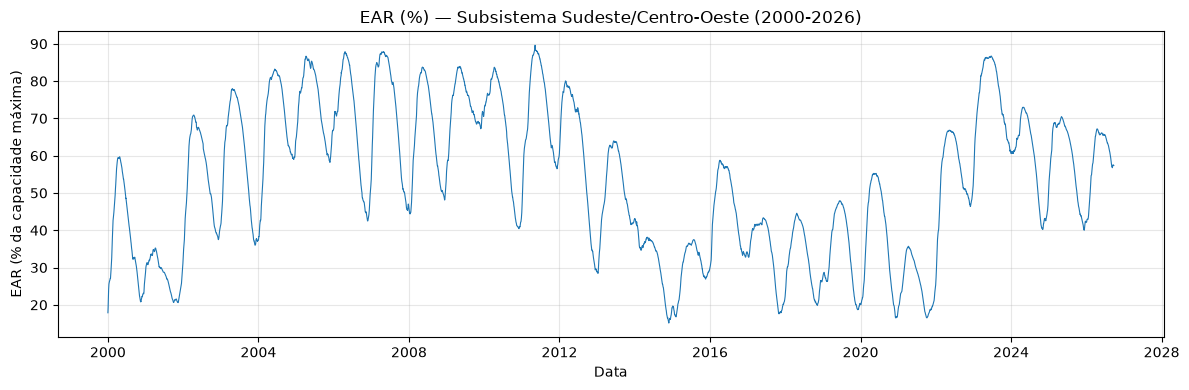

In [7]:
import matplotlib.pyplot as plt
from pathlib import Path

Path("../docs/img").mkdir(parents=True, exist_ok=True)

df_se = df_ear[df_ear["id_subsistema"] == "SE"]

plt.figure(figsize=(12, 4))
plt.plot(df_se["ear_data"], df_se["ear_verif_subsistema_percentual"], linewidth=0.8)
plt.title("EAR (%) — Subsistema Sudeste/Centro-Oeste (2000-2026)")
plt.xlabel("Data")
plt.ylabel("EAR (% da capacidade máxima)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../docs/img/ear_se_serie_completa.png", dpi=120)
plt.show()

# **Modelos**

Descrição metodológica para a criação, refinamento e validação dos modelos propostos.

In [ ]:
# Códigos aqui

# **Resultados**

Apresentar os resultados obtidos, métricas, tabelas comparativas, etc.

# **Dicussão e Conclusão**

Conclusões; análise crítica dos resultados do trabalho (suas qualidades e limitações); alcance do objetivo inicial (a solução do problema); potenciais melhorias no projeto.

# **Apresentação**

Colocar os links do vídeo (apresentação com apoio de slides).

# **Referências**

ABSOLAR – Associação Brasileira de Energia Solar Fotovoltaica. Energia solar 
amplia participação na matriz elétrica enquanto outras fontes recuam. 
CANAL SOLAR, 23 jan. 2026. Disponível em: 
https://canalsolar.com.br/energia-solar-participacao-matriz-eletrica-2/. 
Acesso em: 29 ago. 2026.

CNN BRASIL. Brasil descarta energia enquanto discute as regras. 1 maio 2026. 
Disponível em: 
https://www.cnnbrasil.com.br/infra/brasil-descarta-energia-enquanto-discute-as-regras/. 
Acesso em: 29 ago. 2026.

ENGIE. Curtailment supera 20% da geração eólica e solar em 2025. 13 fev. 2026. 
Disponível em: 
https://www.alemdaenergia.engie.com.br/curtailment-supera-20-da-geracao-eolica-e-solar-em-2025/. 
Acesso em: 29 ago. 2026.

CB INSIGHTS. Brasil desperdiça 20% de sua energia renovável e gera prejuízos 
bilionários a empresas do setor elétrico. Disponível em: 
https://www.cbinsights.com/investor/auren-energia. 
Acesso em: 29 ago. 2026.

SANTOS, R. R. dos; NASCIMENTO, E. L. B. do. Uma crise energética que marcou 
o Brasil: o legado do apagão de 2001 e 2002. Cuadernos de Educación y 
Desarrollo, v. 17, n. 12, e10332, 2025. DOI: https://doi.org/10.55905/cuadv17n12-059. 
Acesso em: 29 ago. 2026.

PÁEZ MENDIETA, J. D.; HIDALGO, I. G. Complementariedade hidro/solar na 
bacia do Alto São Francisco: uma alternativa para gerenciamento de recursos 
hídricos. HOLOS, v. 5, n. 41, 2025. DOI: https://doi.org/10.15628/holos.2025.11254. 
Acesso em: 30 ago. 2026.

AGÊNCIA BRASIL. Aneel aprova consulta pública para reduzir bandeira 
tarifária. 22 ago. 2023. Disponível em: 
https://agenciabrasil.ebc.com.br/economia/noticia/2023-08/aneel-aprova-consulta-publica-para-reduzir-bandeira-tarifaria. 
Acesso em: 29 ago. 2026.

OPERADOR NACIONAL DO SISTEMA ELÉTRICO (ONS). Portal de Dados Abertos. 
Disponível em: https://dados.ons.org.br. Acesso em: 29 ago. 2026.

AGÊNCIA NACIONAL DE ENERGIA ELÉTRICA (ANEEL). Portal de Dados Abertos. 
Disponível em: https://dadosabertos.aneel.gov.br. Acesso em: 29 ago. 2026.

AGÊNCIA NACIONAL DE ENERGIA ELÉTRICA (ANEEL); CÂMARA DE REGRAS 
EXCEPCIONAIS PARA GESTÃO HIDROENERGÉTICA (CREG). Resolução CREG nº 3, 
de 31 de agosto de 2021. Institui a Bandeira Tarifária de Escassez Hídrica. 
Disponível em: https://www2.aneel.gov.br/cedoc/res2021003creg.pdf. 
Acesso em: 29 ago. 2026.

MINE, M. R. M.; TUCCI, C. E. M. Gerenciamento da produção de energia
e controle de inundação: Foz do Areia no rio Iguaçu. RBRH – Revista
Brasileira de Recursos Hídricos, v. 7, n. 3, p. 85-107, jul./set. 2002.

NUNES, L. R. M.; VERAS, J. S.; SILVA, J. P. R. Uso do ARIMA e SVM
para previsão de séries temporais do sistema elétrico brasileiro.
Research, Society and Development, v. 12, n. 3, e8112340438, 2023.
DOI: http://dx.doi.org/10.33448/rsd-v12i3.40438. Acesso em: 26 set. 2026.